# *Pneumonia Detection from Chest X-Ray Images Using Deep Learning–Based Medical Image Analysis*

Dataset Link : https://www.kaggle.com/datasets/kmljts/pneumonia-multiclass

## **Dataset Downloading**

**Google Colab**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kmljts/pneumonia-multiclass

!unzip -q pneumonia-multiclass.zip

Dataset URL: https://www.kaggle.com/datasets/kmljts/pneumonia-multiclass
License(s): apache-2.0
100% 1.14G/1.14G [00:30<00:00, 40.5MB/s]



**Libraries**

In [4]:
import os
import shutil
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
import random
from PIL import Image
warnings.filterwarnings('ignore')

## **Raw Image Data Preprocessing**

In [5]:
parent_dir = "chest_xray"
print(f"All folders/classes in our dataset are")
for i in os.listdir(parent_dir):
    print(i)

All folders/classes in our dataset are
PNEUMONIA_BACTERIAL
PNEUMONIA_VIRAL
NORMAL


**Renaming Folder Names**

In [6]:
# Train Image Dir renaming
def renaming(list_of_dirs, dir_path):
    for r in range(len(list_of_dirs)):
        old_path = os.path.join(dir_path, list_of_dirs[r])
        new_path = os.path.join(dir_path, list_of_dirs[r].replace("_", " "))
        os.rename(old_path, new_path)
    print(f"{dir_path} successfully renamed")

renaming(os.listdir(parent_dir), parent_dir)

chest_xray successfully renamed


**Count of images in each class**

In [7]:
count_images_dir = {}
for d in os.listdir(parent_dir):
    count_images_dir[d] = len(os.listdir(os.path.join(parent_dir, d)))
    print(f"{d} has {len(os.listdir(os.path.join(parent_dir, d)))}")

PNEUMONIA BACTERIAL has 2780
NORMAL has 1583
PNEUMONIA VIRAL has 1493


In [8]:
count_images_dir

{'PNEUMONIA BACTERIAL': 2780, 'NORMAL': 1583, 'PNEUMONIA VIRAL': 1493}

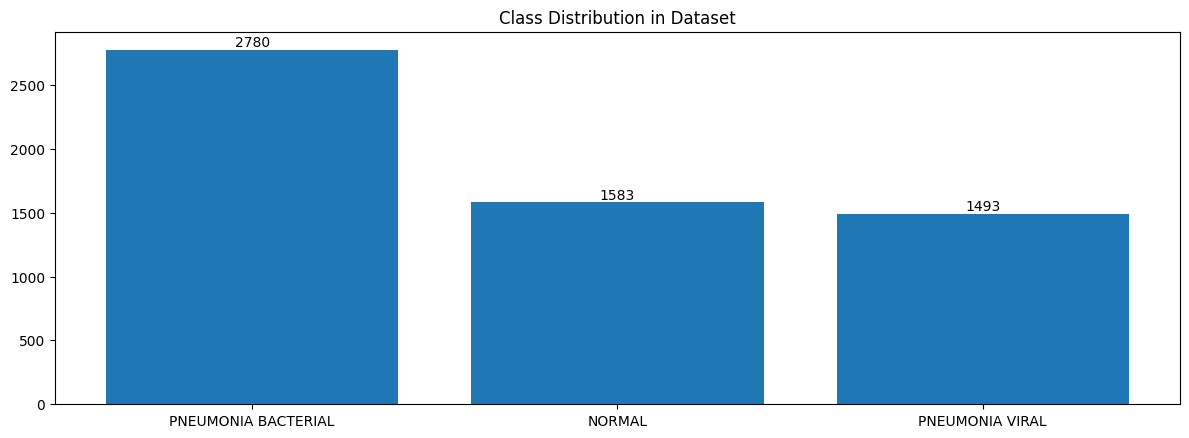

In [9]:
plt.figure(figsize=(12,6))

bars = plt.bar(list(count_images_dir.keys()), list(count_images_dir.values()))

plt.xticks(rotation=90)
plt.title("Class Distribution in Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

**Checking how many are grayscale and colormap for all classes**

In [10]:
import cv2

dataset_path = parent_dir

def is_grayscale(img):
    # If single channel -> grayscale
    if len(img.shape) == 2:
        return True

    # If 3-channel but all channels equal -> grayscale
    if len(img.shape) == 3:
        b, g, r = cv2.split(img)
        if np.array_equal(b, g) and np.array_equal(g, r):
            return True

    return False

results = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    gray_count = 0
    color_count = 0

    for file in os.listdir(class_path):
        file_path = os.path.join(class_path, file)

        img = cv2.imread(file_path)

        if img is None:
            continue

        if is_grayscale(img):
            gray_count += 1
        else:
            color_count += 1

    results[class_name] = {
        "Grayscale": gray_count,
        "Colormap/RGB": color_count
    }

# Print results
for cls, counts in results.items():
    print(f"\nClass: {cls}")
    print(f"Grayscale Images   : {counts['Grayscale']}")
    print(f"Colormap/RGB Images: {counts['Colormap/RGB']}")


Class: PNEUMONIA BACTERIAL
Grayscale Images   : 2780
Colormap/RGB Images: 0

Class: NORMAL
Grayscale Images   : 1583
Colormap/RGB Images: 0

Class: PNEUMONIA VIRAL
Grayscale Images   : 1493
Colormap/RGB Images: 0


**Sample data visualization**

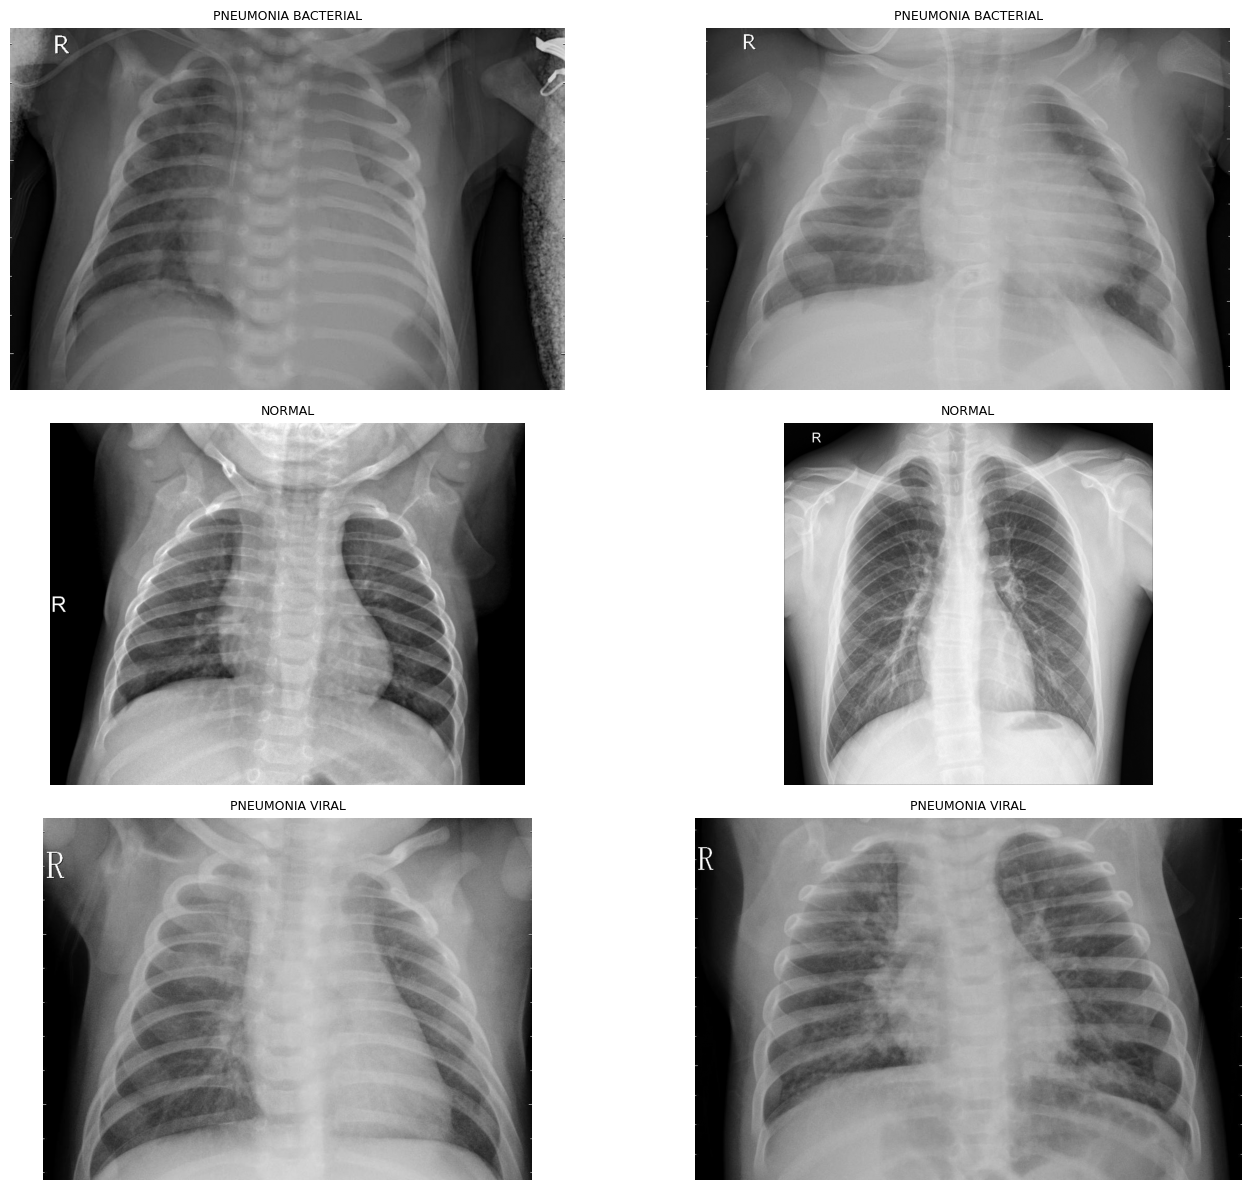

In [11]:
classes = os.listdir(parent_dir)

images_per_class = 2
total_images = len(classes) * images_per_class

cols = 2
rows = 3

plt.figure(figsize=(15, 4 * rows))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(parent_dir, class_name)

    images = random.sample(os.listdir(class_path), images_per_class)

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(rows, cols, plot_index)
        plt.imshow(img, cmap='gray')
        plt.title(class_name, fontsize=9)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

#### **Train, Test and Validation Split**

In [12]:
# Paths
source_dir = parent_dir
target_dir = "Split Data"

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".jpeg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


**Train Data Count**

In [13]:
train_dir = "Split Data/train"

list_of_directories = os.listdir(train_dir)
counts = []

for dir in list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    counts.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

PNEUMONIA BACTERIAL has 1945 images
NORMAL has 1108 images
PNEUMONIA VIRAL has 1045 images


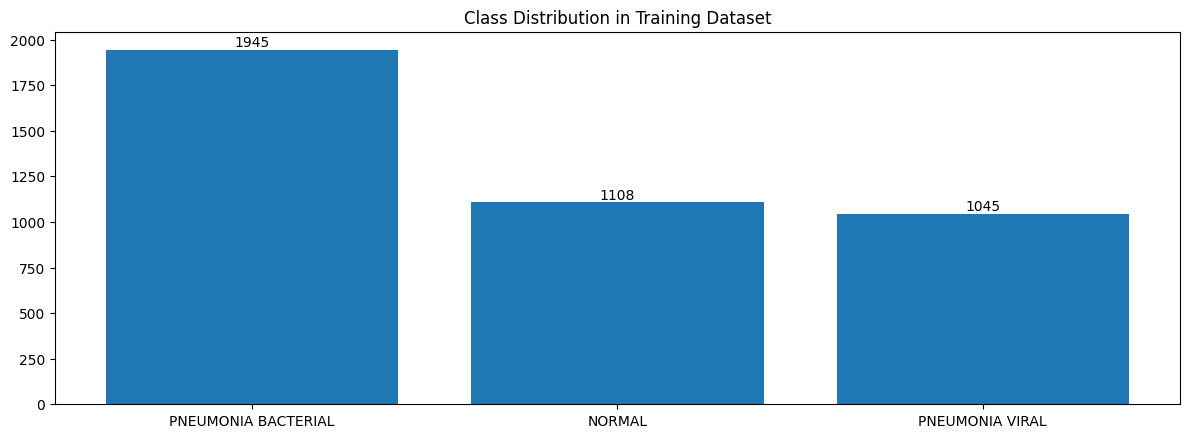

In [14]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories, counts)

plt.xticks(rotation=90)
plt.title("Class Distribution in Training Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

**Validation Data Count**

In [15]:
val_dir = "Split Data/val"

list_of_directories_valid = os.listdir(val_dir)
valid_count_images = []

for dir in list_of_directories_valid:
    dir_path = os.path.join(val_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    valid_count_images.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

PNEUMONIA BACTERIAL has 417 images
NORMAL has 237 images
PNEUMONIA VIRAL has 223 images


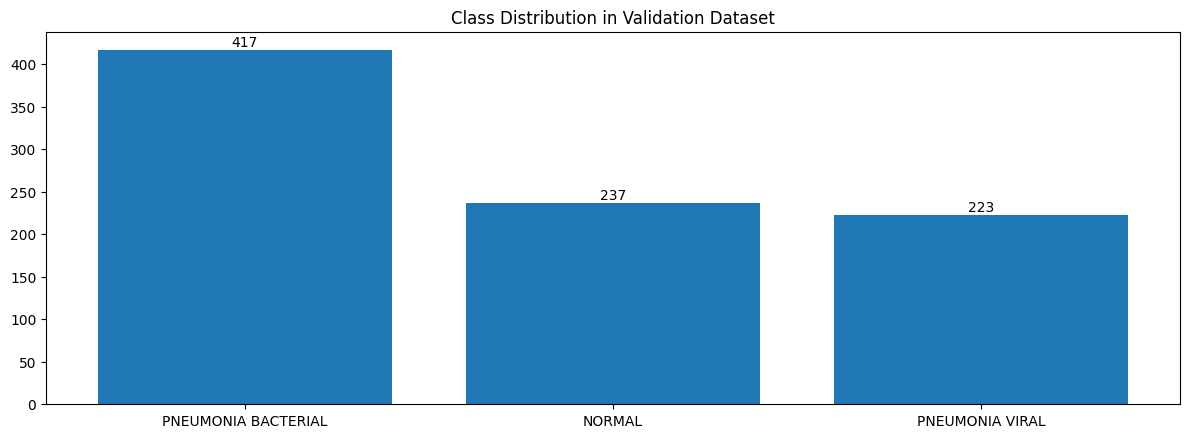

In [16]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories_valid, valid_count_images)

plt.xticks(rotation=90)
plt.title("Class Distribution in Validation Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

**Test Data Count**

In [17]:
test_dir = "Split Data/test"

list_of_directories_test = os.listdir(test_dir)
test_count_images = []

for dir in list_of_directories_test:
    dir_path = os.path.join(test_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    test_count_images.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

PNEUMONIA BACTERIAL has 418 images
NORMAL has 238 images
PNEUMONIA VIRAL has 225 images


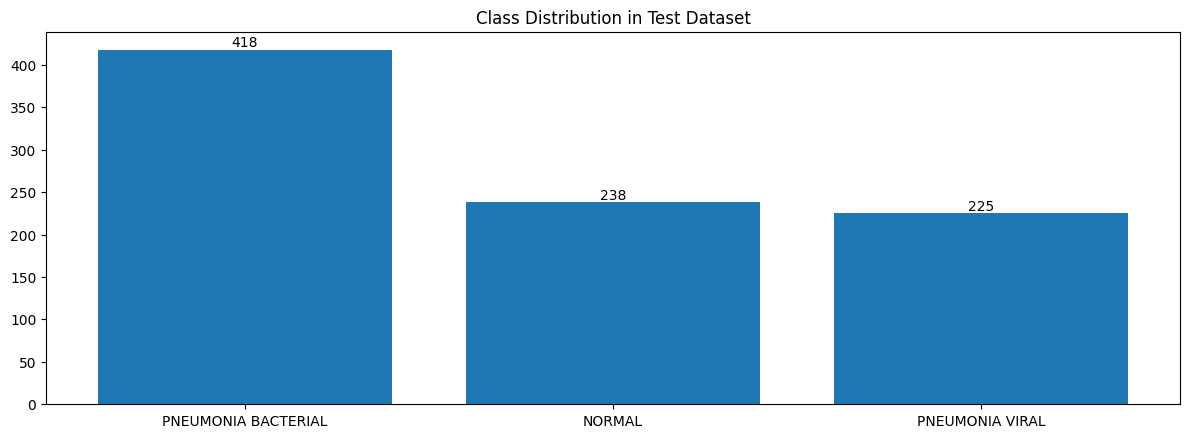

In [18]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories_test, test_count_images)

plt.xticks(rotation=90)
plt.title("Class Distribution in Test Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

## **Data Augmentation**

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
train_dir = "Split Data/train"
val_dir = "Split Data/val"
test_dir = "Split Data/test"

In [21]:
batch_size=64
img_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 4098 images belonging to 3 classes.


In [22]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 877 images belonging to 3 classes.
Found 881 images belonging to 3 classes.


## **Check for Class Imbalance**

In [23]:
import numpy as np
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

print("\nClass Distribution:")
for class_name, idx in class_labels.items():
    print(f"{class_name}: {counts[idx]}")

Class Labels: {'NORMAL': 0, 'PNEUMONIA BACTERIAL': 1, 'PNEUMONIA VIRAL': 2}

Class Distribution:
NORMAL: 1108
PNEUMONIA BACTERIAL: 1945
PNEUMONIA VIRAL: 1045


In [24]:
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")


Imbalance Ratio: 1.86


In [25]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(1.2328519855595668), 1: np.float64(0.7023136246786632), 2: np.float64(1.307177033492823)}


## **Model Building**

In [26]:
all_model_metrics = []
epochs = 20

In [27]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import F1Score

#### **ResNet50**

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [29]:
# Load ResNet50 base model
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model_resnet.layers[:140]:
    layer.trainable = False
for layer in base_model_resnet.layers[140:]:
    layer.trainable = True

# Build custom classification layers on top of ResNet50
x = base_model_resnet.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

resnet_model = Model(inputs=base_model_resnet.input, outputs=predictions)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [30]:
resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001), # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [31]:
resnet_history = resnet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.5264 - f1_score: 0.5193 - loss: 1.2420 - precision: 0.5459 - recall: 0.4878 - val_accuracy: 0.2725 - val_f1_score: 0.1581 - val_loss: 1.1440 - val_precision: 0.2436 - val_recall: 0.0217
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5813 - f1_score: 0.5757 - loss: 1.0563 - precision: 0.5984 - recall: 0.5520 - val_accuracy: 0.2554 - val_f1_score: 0.1381 - val_loss: 1.3795 - val_precision: 0.2561 - val_recall: 0.2531
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.5932 - f1_score: 0.5843 - loss: 1.0379 - precision: 0.6053 - recall: 0.5576 - val_accuracy: 0.3615 - val_f1_score: 0.3327 - val_loss: 1.2993 - val_precision: 0.3602 - val_recall: 0.2748
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.6115 - f1_score: 0.6065 - loss: 0.9676 - precision: 0.6322 - recall: 0.5847 - val_accuracy: 0.5507 - val_f1_score: 0.5628 - val_loss: 0.8821 - val_precision: 0.5943 - val_recall: 0.3774

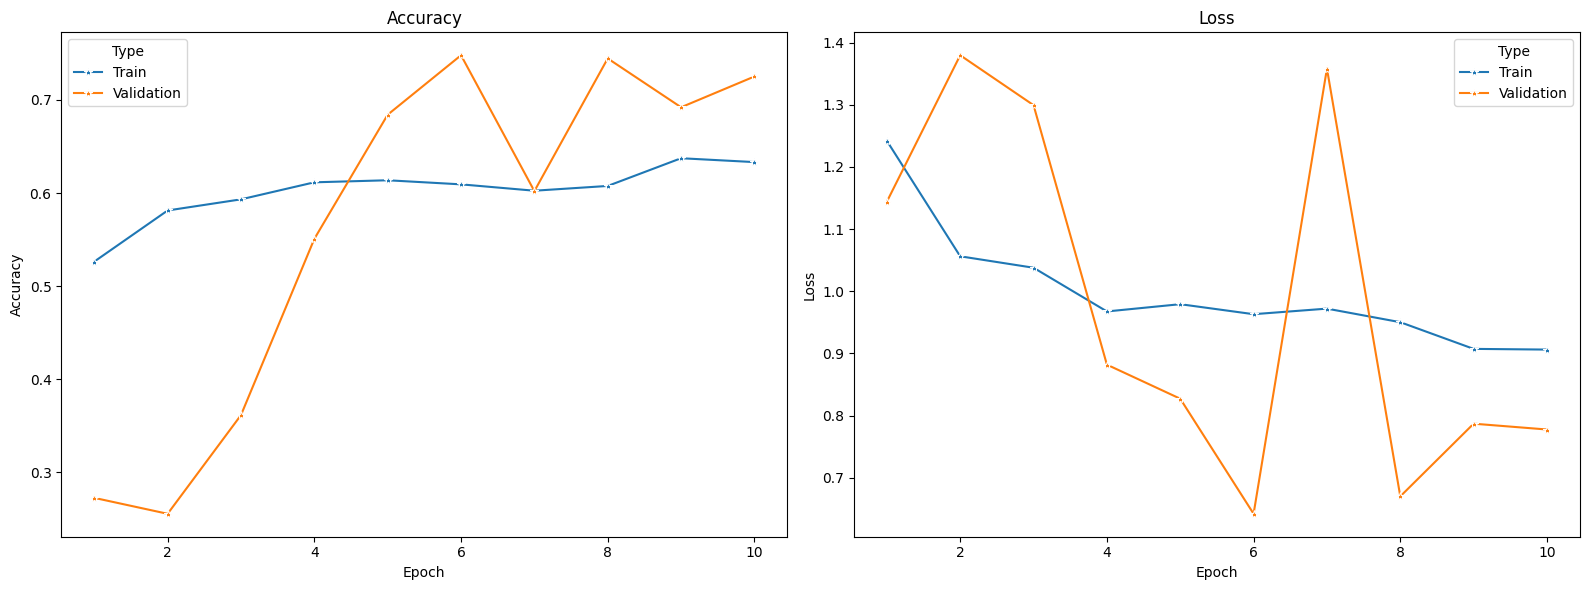

In [32]:
acc = resnet_history.history['accuracy']
val_acc = resnet_history.history['val_accuracy']
loss = resnet_history.history['loss']
val_loss = resnet_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

In [33]:
resnet_loss, resnet_accuracy, resnet_precision, resnet_recall, resnet_f1 = resnet_model.evaluate(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7526 - f1_score: 0.7313 - loss: 0.6576 - precision: 0.7622 - recall: 0.7276


In [34]:
print(f"Test Loss of resnet: {resnet_loss:.4f}")
print(f"Test Accuracy of resNet: {resnet_accuracy * 100:.2f}%")
print(f"Test Precision of resNet: {resnet_precision:.4f}")
print(f"Test Recall of resNet: {resnet_recall:.4f}")
print(f"Test F1 Score of resNet: {resnet_f1:.4f}")

Test Loss of resnet: 0.6576
Test Accuracy of resNet: 75.26%
Test Precision of resNet: 0.7622
Test Recall of resNet: 0.7276
Test F1 Score of resNet: 0.7313


In [35]:
resnet_metrics = {
    "Model Name": "ResNet Model",
    "Accuracy":resnet_accuracy,
    "Precision":resnet_precision,
    "Recall":resnet_recall,
    "F1":resnet_f1
}

all_model_metrics.append(resnet_metrics)

#### **DenseNet-121**

In [36]:
from tensorflow.keras.applications import DenseNet121

# Load DenseNet121 base model
base_model_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze some layers for fine-tuning
for layer in base_model_densenet.layers[:300]: # Freeze first 300 layers
    layer.trainable = False
for layer in base_model_densenet.layers[300:]:
    layer.trainable = True

# Build custom classification layers on top of DenseNet121
x = base_model_densenet.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

densenet_model = Model(inputs=base_model_densenet.input, outputs=predictions)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [37]:
densenet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [38]:
densenet_history = densenet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.5183 - f1_score: 0.5104 - loss: 1.2419 - precision: 0.5310 - recall: 0.4793 - val_accuracy: 0.5861 - val_f1_score: 0.5593 - val_loss: 1.0454 - val_precision: 0.6061 - val_recall: 0.5211
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.6276 - f1_score: 0.6212 - loss: 0.9921 - precision: 0.6432 - recall: 0.6018 - val_accuracy: 0.6727 - val_f1_score: 0.6507 - val_loss: 0.8748 - val_precision: 0.6913 - val_recall: 0.6408
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.6608 - f1_score: 0.6546 - loss: 0.9047 - precision: 0.6771 - recall: 0.6359 - val_accuracy: 0.6944 - val_f1_score: 0.6722 - val_loss: 0.7904 - val_precision: 0.7167 - val_recall: 0.6693
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.6611 - f1_score: 0.6574 - loss: 0.8768 - precision: 0.6764 - recall: 0.6413 - val_accuracy: 0.7298 - val_f1_score: 0.7145 - val_loss: 0.7026 - val_precision: 0.7470 - val_recall: 0.7104

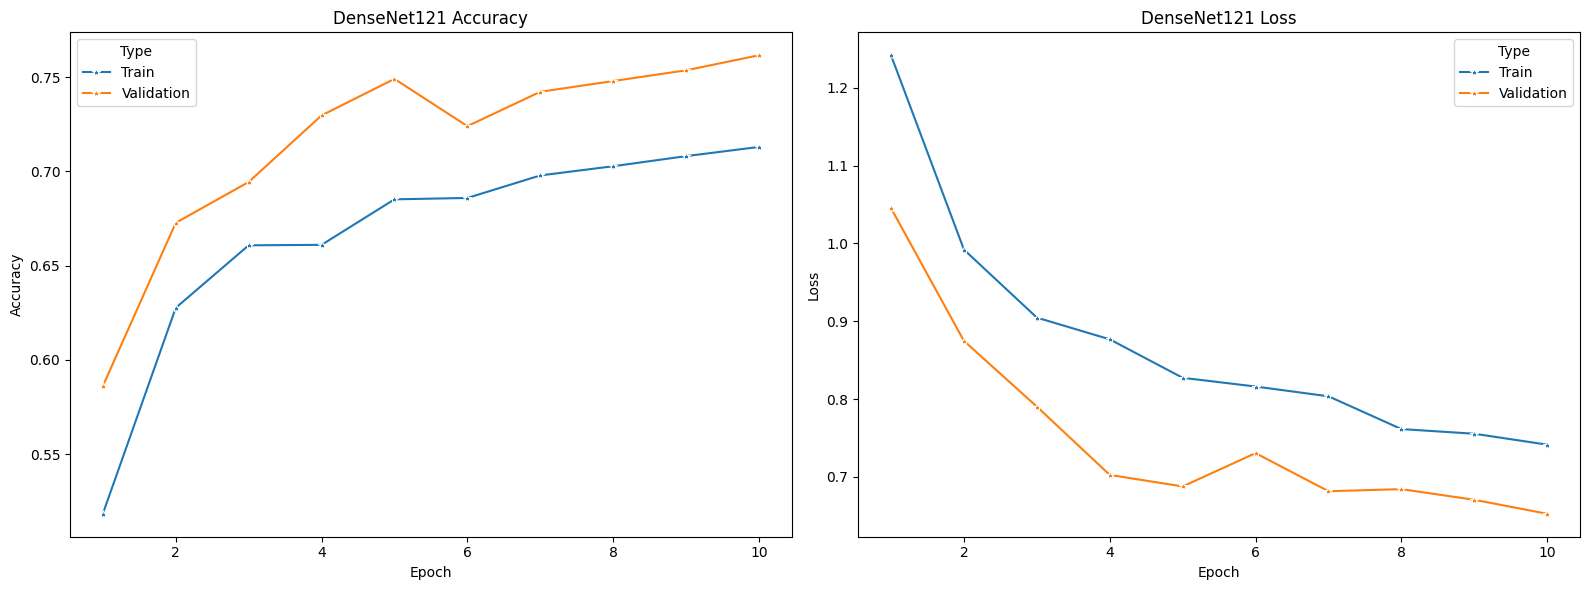

In [39]:
acc = densenet_history.history['accuracy']
val_acc = densenet_history.history['val_accuracy']
loss = densenet_history.history['loss']
val_loss = densenet_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('DenseNet121 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('DenseNet121 Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

In [40]:
densenet_loss, densenet_accuracy, densenet_precision, densenet_recall, densenet_f1 = densenet_model.evaluate(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5619 - f1_score: 0.5348 - loss: 1.1000 - precision: 0.5741 - recall: 0.4835


In [41]:
print(f"Test Loss of DenseNet121: {densenet_loss:.4f}")
print(f"Test Accuracy of DenseNet121: {densenet_accuracy * 100:.2f}%")
print(f"Test Precision of DenseNet121: {densenet_precision:.4f}")
print(f"Test Recall of DenseNet121: {densenet_recall:.4f}")
print(f"Test F1 Score of DenseNet121: {densenet_f1:.4f}")

densenet_metrics = {
    "Model Name": "DenseNet121 Model",
    "Accuracy": densenet_accuracy,
    "Precision": densenet_precision,
    "Recall": densenet_recall,
    "F1": densenet_f1
}

all_model_metrics.append(densenet_metrics)

Test Loss of DenseNet121: 1.1000
Test Accuracy of DenseNet121: 56.19%
Test Precision of DenseNet121: 0.5741
Test Recall of DenseNet121: 0.4835
Test F1 Score of DenseNet121: 0.5348


#### **EfficientNet**

In [42]:
from tensorflow.keras.applications import EfficientNetB0

# Load EfficientNetB0 base model
base_model_efficientnet = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze some layers for fine-tuning
for layer in base_model_efficientnet.layers[:-50]: # Freeze most layers, fine-tune the last few
    layer.trainable = False
for layer in base_model_efficientnet.layers[-50:]:
    layer.trainable = True

# Build custom classification layers on top of EfficientNetB0
x = base_model_efficientnet.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

efficientnet_model = Model(inputs=base_model_efficientnet.input, outputs=predictions)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [43]:
efficientnet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [44]:
efficientnet_history = efficientnet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.3348 - f1_score: 0.3273 - loss: 1.6528 - precision: 0.3348 - recall: 0.2640 - val_accuracy: 0.2543 - val_f1_score: 0.1352 - val_loss: 1.1257 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3248 - f1_score: 0.3163 - loss: 1.6060 - precision: 0.3261 - recall: 0.2491 - val_accuracy: 0.2543 - val_f1_score: 0.1352 - val_loss: 1.3096 - val_precision: 0.2543 - val_recall: 0.2543
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3431 - f1_score: 0.3347 - loss: 1.5675 - precision: 0.3339 - recall: 0.2496 - val_accuracy: 0.2543 - val_f1_score: 0.1352 - val_loss: 1.5964 - val_precision: 0.2543 - val_recall: 0.2543
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3492 - f1_score: 0.3425 - loss: 1.5400 - precision: 0.3517 - recall: 0.2604 - val_accuracy: 0.2543 - val_f1_score: 0.1352 - val_loss: 1.4314 - val_precision: 0.2543 - val_recall

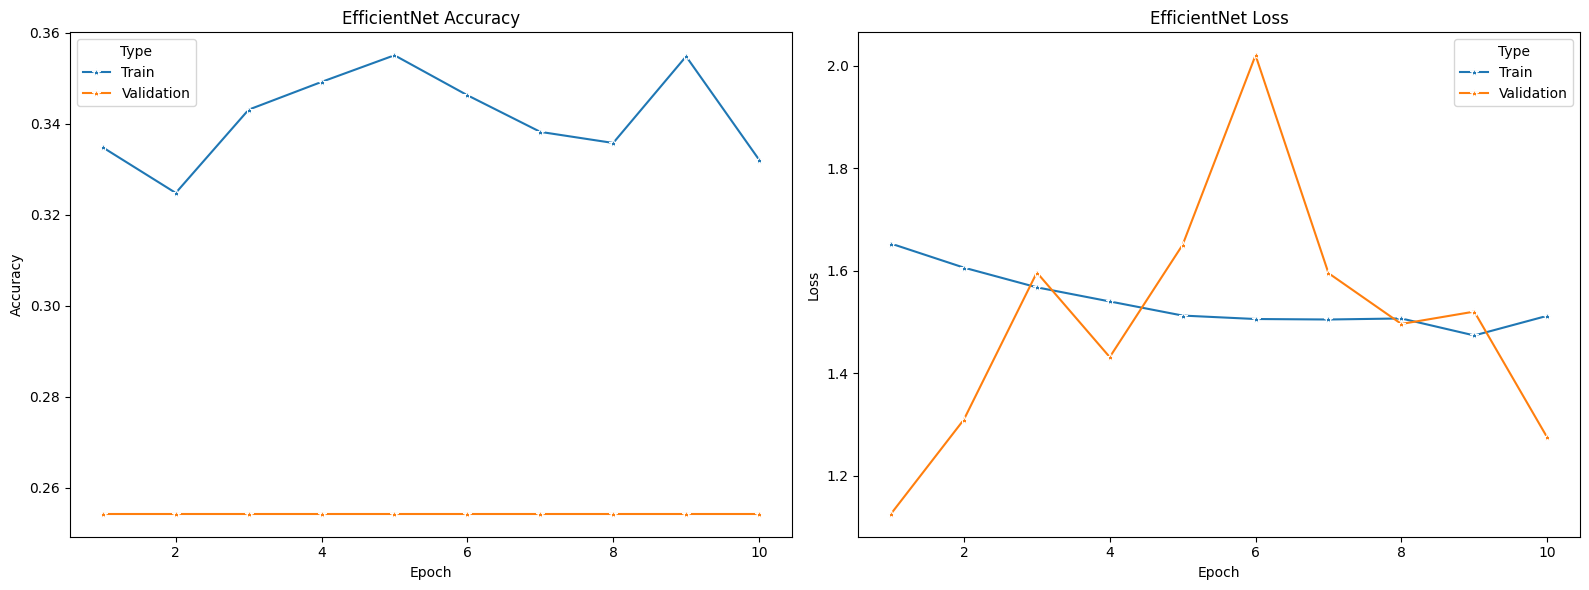

In [45]:
acc = efficientnet_history.history['accuracy']
val_acc = efficientnet_history.history['val_accuracy']
loss = efficientnet_history.history['loss']
val_loss = efficientnet_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('EfficientNet Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('EfficientNet Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

In [46]:
efficientnet_loss, efficientnet_accuracy, efficientnet_precision, efficientnet_recall, efficientnet_f1 = efficientnet_model.evaluate(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2554 - f1_score: 0.1356 - loss: 1.1255 - precision: 0.0000e+00 - recall: 0.0000e+00


In [47]:
print(f"Test Loss of EfficientNet: {efficientnet_loss:.4f}")
print(f"Test Accuracy of EfficientNet: {efficientnet_accuracy * 100:.2f}%")
print(f"Test Precision of EfficientNet: {efficientnet_precision:.4f}")
print(f"Test Recall of EfficientNet: {efficientnet_recall:.4f}")
print(f"Test F1 Score of EfficientNet: {efficientnet_f1:.4f}")

efficientnet_metrics = {
    "Model Name": "EfficientNet Model",
    "Accuracy": efficientnet_accuracy,
    "Precision": efficientnet_precision,
    "Recall": efficientnet_recall,
    "F1": efficientnet_f1
}

all_model_metrics.append(efficientnet_metrics)

Test Loss of EfficientNet: 1.1255
Test Accuracy of EfficientNet: 25.54%
Test Precision of EfficientNet: 0.0000
Test Recall of EfficientNet: 0.0000
Test F1 Score of EfficientNet: 0.1356


## **Plots**

14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 836ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 984ms/step


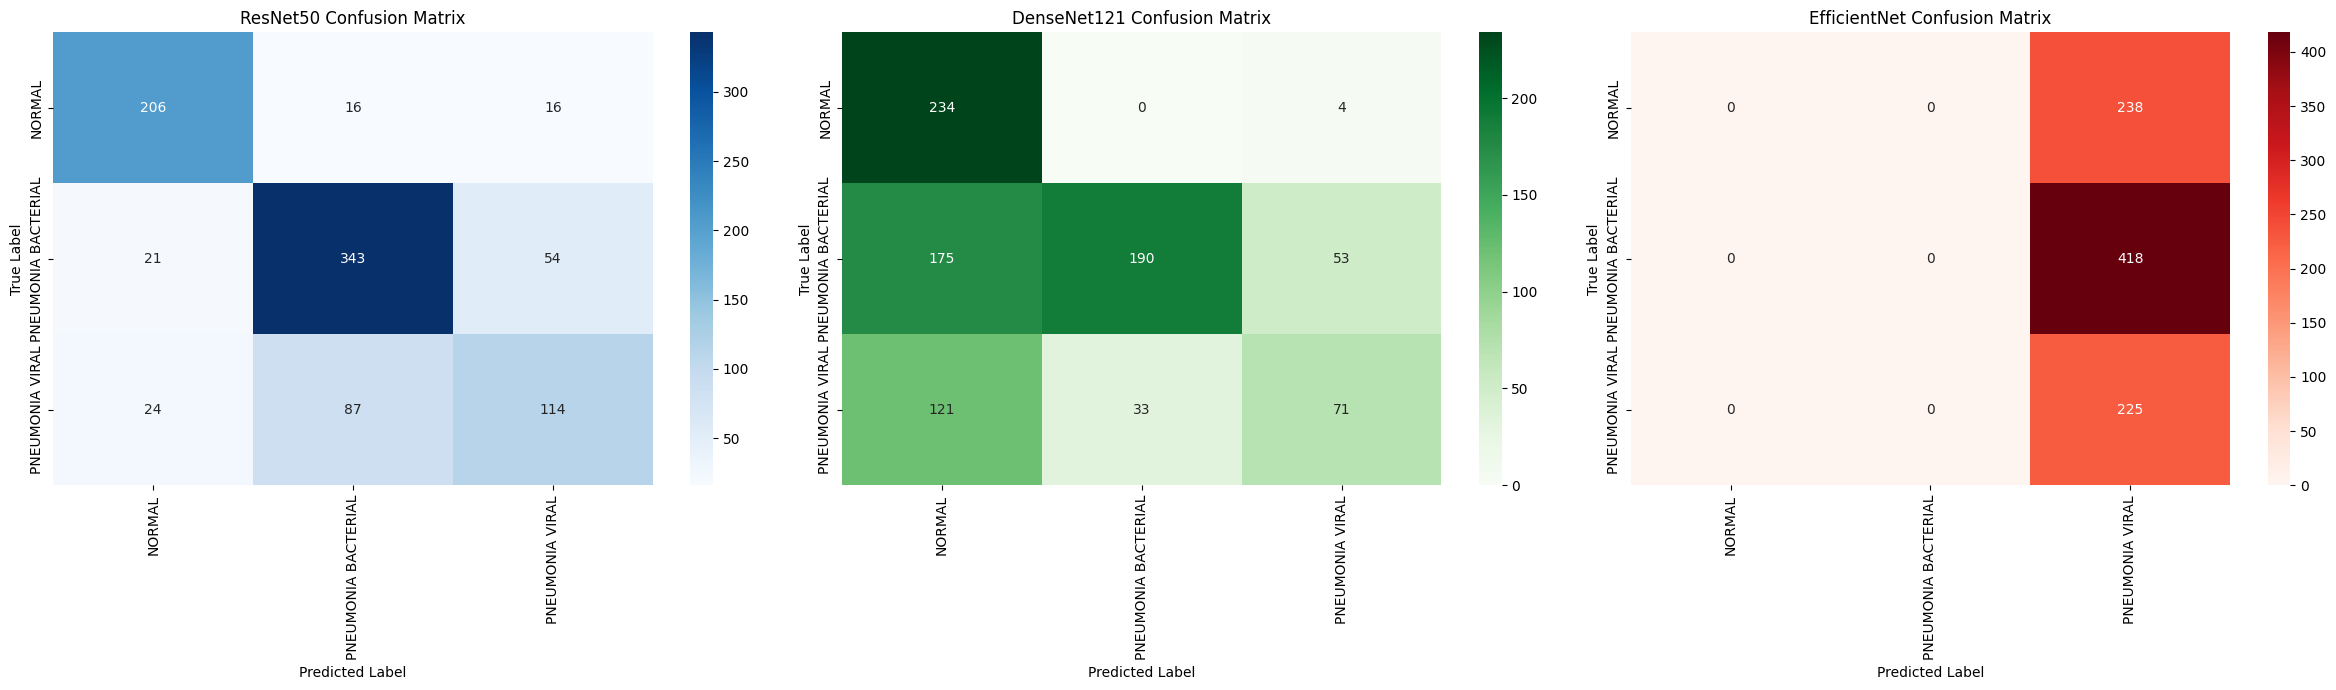

In [48]:
from sklearn.metrics import confusion_matrix

# Get true labels from the test generator
true_labels = test_generator.classes

# Get class names for labeling the plots
class_names = list(train_generator.class_indices.keys())

# Make predictions for each model
resnet_predictions = resnet_model.predict(test_generator)
densenet_predictions = densenet_model.predict(test_generator)
efficientnet_predictions = efficientnet_model.predict(test_generator)

# Convert predictions to class labels
resnet_pred_labels = np.argmax(resnet_predictions, axis=1)
densenet_pred_labels = np.argmax(densenet_predictions, axis=1)
efficientnet_pred_labels = np.argmax(efficientnet_predictions, axis=1)

# Calculate confusion matrices
cm_resnet = confusion_matrix(true_labels, resnet_pred_labels)
cm_densenet = confusion_matrix(true_labels, densenet_pred_labels)
cm_efficientnet = confusion_matrix(true_labels, efficientnet_pred_labels)

# Create a figure with 1 row and 3 columns for the plots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot Confusion Matrix for ResNet50
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('ResNet50 Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Confusion Matrix for DenseNet121
sns.heatmap(cm_densenet, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('DenseNet121 Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Plot Confusion Matrix for EfficientNet
sns.heatmap(cm_efficientnet, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names, ax=axes[2])
axes[2].set_title('EfficientNet Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [49]:
metrics_df = pd.DataFrame(all_model_metrics)
display(metrics_df.set_index('Model Name'))

,Accuracy,Precision,Recall,F1
Model Name,,,,
ResNet Model,0.752554,0.762188,0.727582,0.731325
DenseNet121 Model,0.561862,0.574124,0.483541,0.534822
EfficientNet Model,0.255392,0.000000,0.000000,0.135624


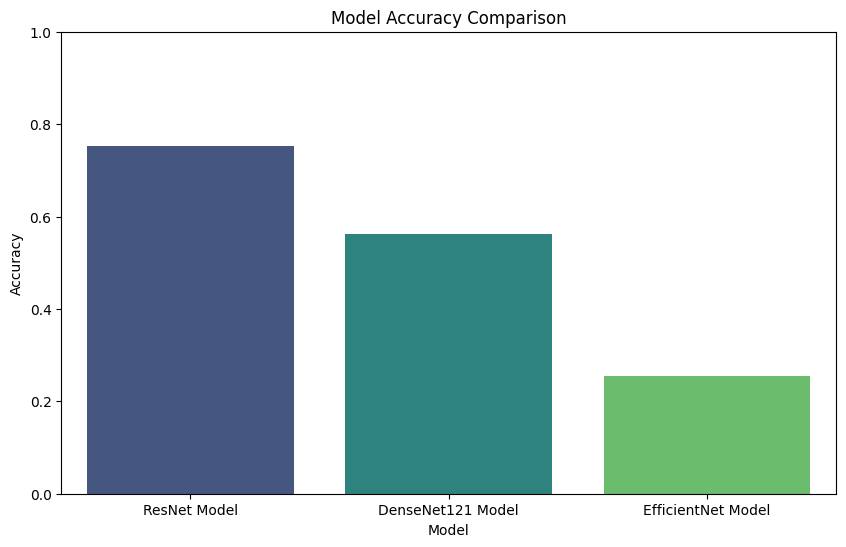

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Accuracy', data=metrics_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.show()

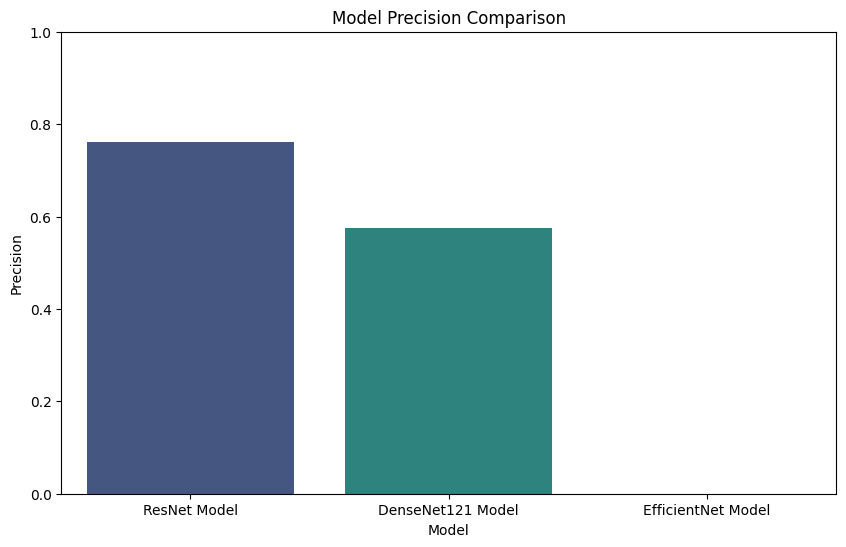

In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Precision', data=metrics_df, palette='viridis')
plt.title('Model Precision Comparison')
plt.xlabel('Model')
plt.ylabel('Precision')
plt.ylim(0, 1) # Precision is between 0 and 1
plt.show()

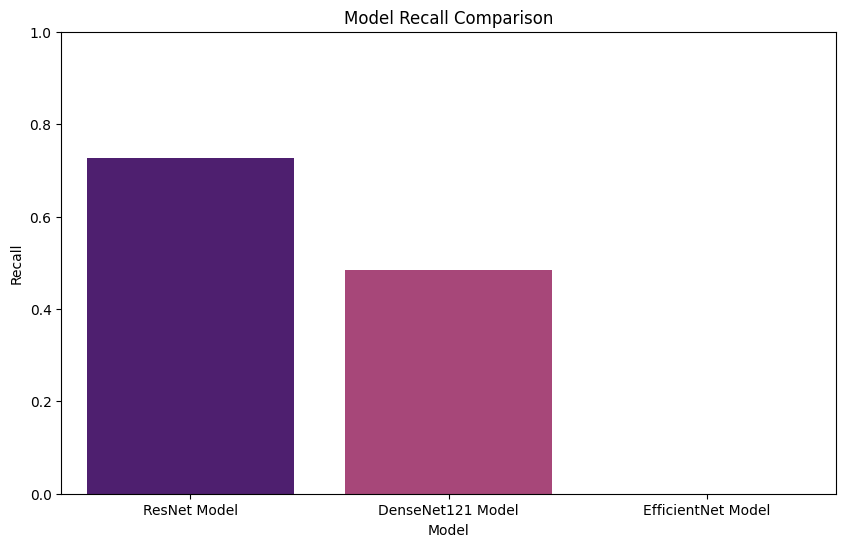

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Recall', data=metrics_df, palette='magma')
plt.title('Model Recall Comparison')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.ylim(0, 1) # Recall is between 0 and 1
plt.show()

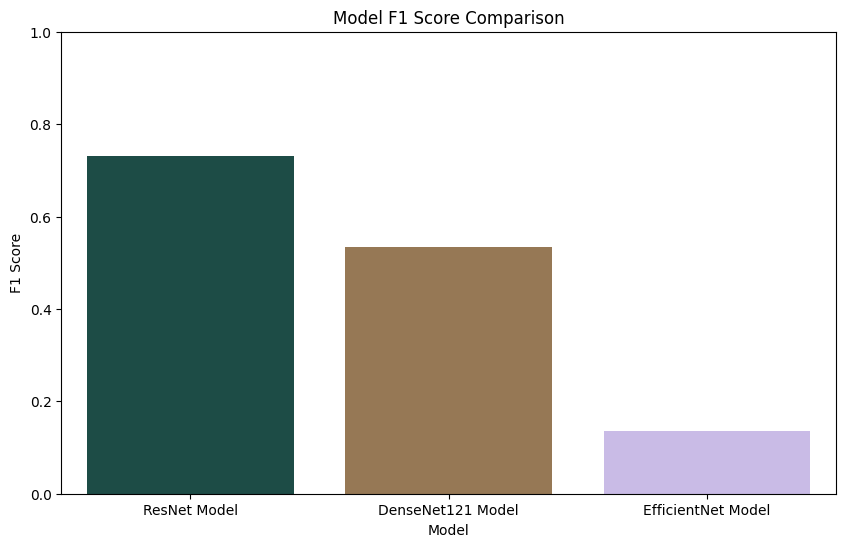

In [53]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='F1', data=metrics_df, palette='cubehelix')
plt.title('Model F1 Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.ylim(0, 1) # F1 Score is between 0 and 1
plt.show()

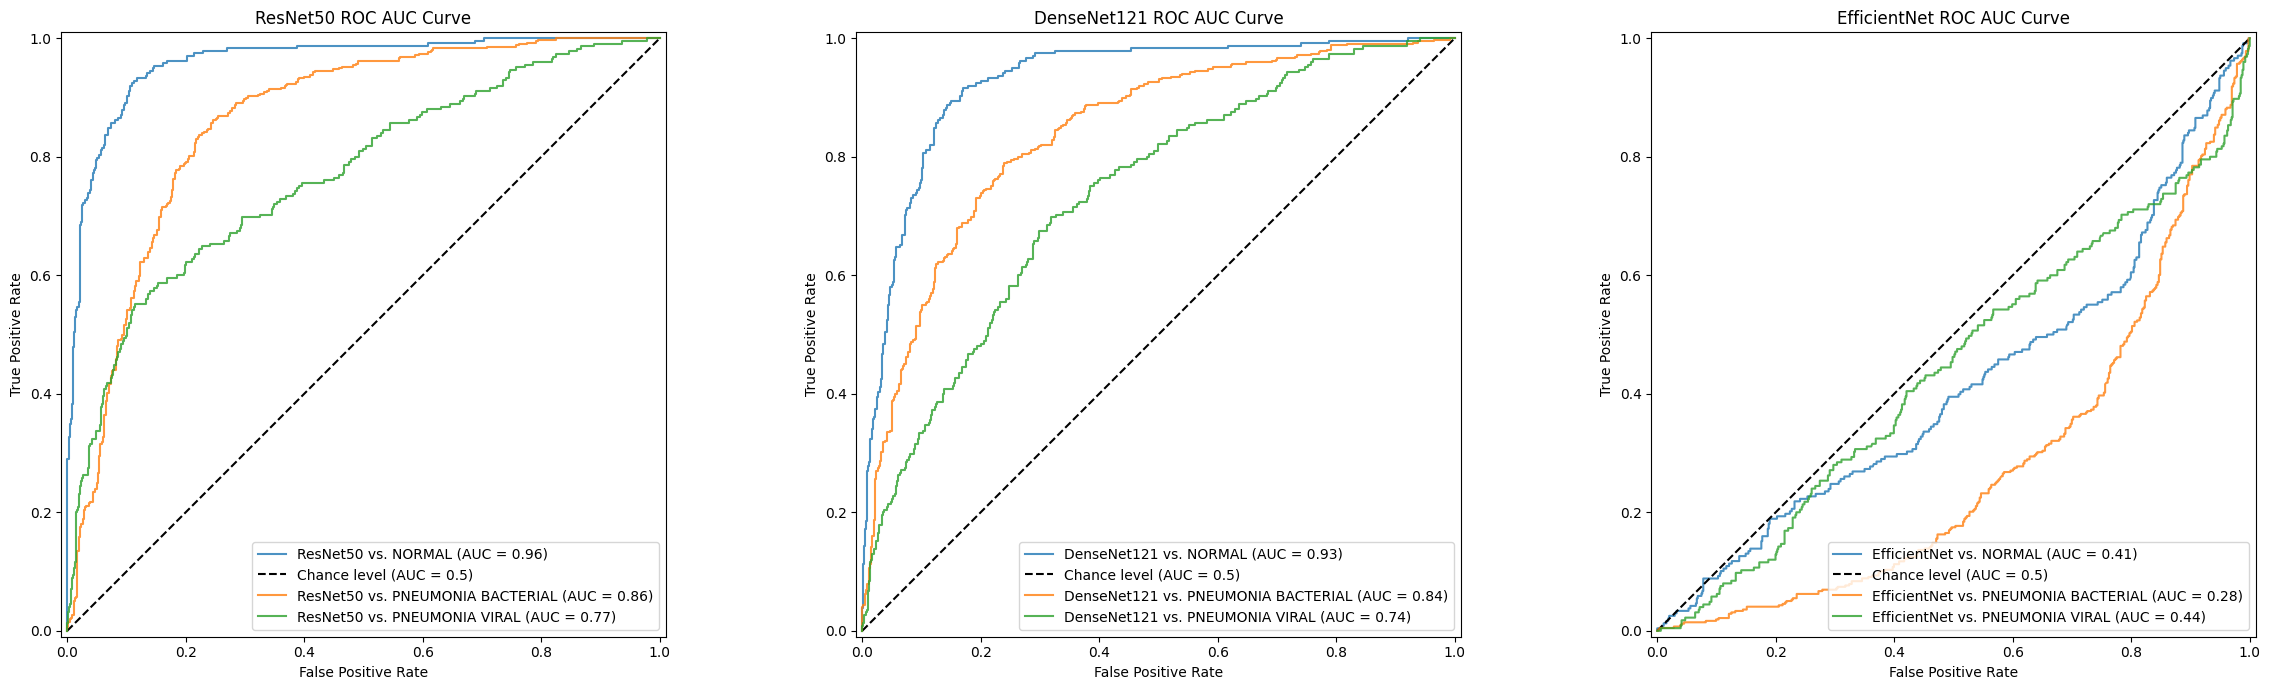

In [54]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer

# Get true labels and one-hot encode them for multi-class ROC
y_true = test_generator.classes

# Instantiate LabelBinarizer and fit on the true labels
label_binarizer = LabelBinarizer()
label_binarizer.fit(y_true)
y_true_one_hot = label_binarizer.transform(y_true)

# Make predictions (probabilities) for each model
# resnet_predictions, densenet_predictions, efficientnet_predictions are already available

# Get class names for labeling
class_names = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot ROC AUC for ResNet50
for i in range(len(class_names)):
    RocCurveDisplay.from_predictions(
        y_true_one_hot[:, i], # True labels for current class
        resnet_predictions[:, i], # Predicted probabilities for current class
        name=f"ResNet50 vs. {class_names[i]}",
        ax=axes[0],
        alpha=0.8,
        plot_chance_level=(i == 0) # Plot chance level only once per subplot
    )
axes[0].set_title('ResNet50 ROC AUC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

# Plot ROC AUC for DenseNet121
for i in range(len(class_names)):
    RocCurveDisplay.from_predictions(
        y_true_one_hot[:, i],
        densenet_predictions[:, i],
        name=f"DenseNet121 vs. {class_names[i]}",
        ax=axes[1],
        alpha=0.8,
        plot_chance_level=(i == 0)
    )
axes[1].set_title('DenseNet121 ROC AUC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

# Plot ROC AUC for EfficientNet
for i in range(len(class_names)):
    RocCurveDisplay.from_predictions(
        y_true_one_hot[:, i],
        efficientnet_predictions[:, i],
        name=f"EfficientNet vs. {class_names[i]}",
        ax=axes[2],
        alpha=0.8,
        plot_chance_level=(i == 0)
    )
axes[2].set_title('EfficientNet ROC AUC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')

plt.tight_layout()
plt.show()

## **Test Predictions**

In [55]:
best_model_row = metrics_df.loc[metrics_df['F1'].idxmax()]
best_model_name = best_model_row['Model Name']

if "ResNet" in best_model_name:
    best_model = resnet_model
elif "DenseNet" in best_model_name:
    best_model = densenet_model
elif "EfficientNet" in best_model_name:
    best_model = efficientnet_model
else:
    print("Error: Best model not identified.")
    best_model = None

print(f"The best model based on F1-score is: {best_model_name}")

The best model based on F1-score is: ResNet Model


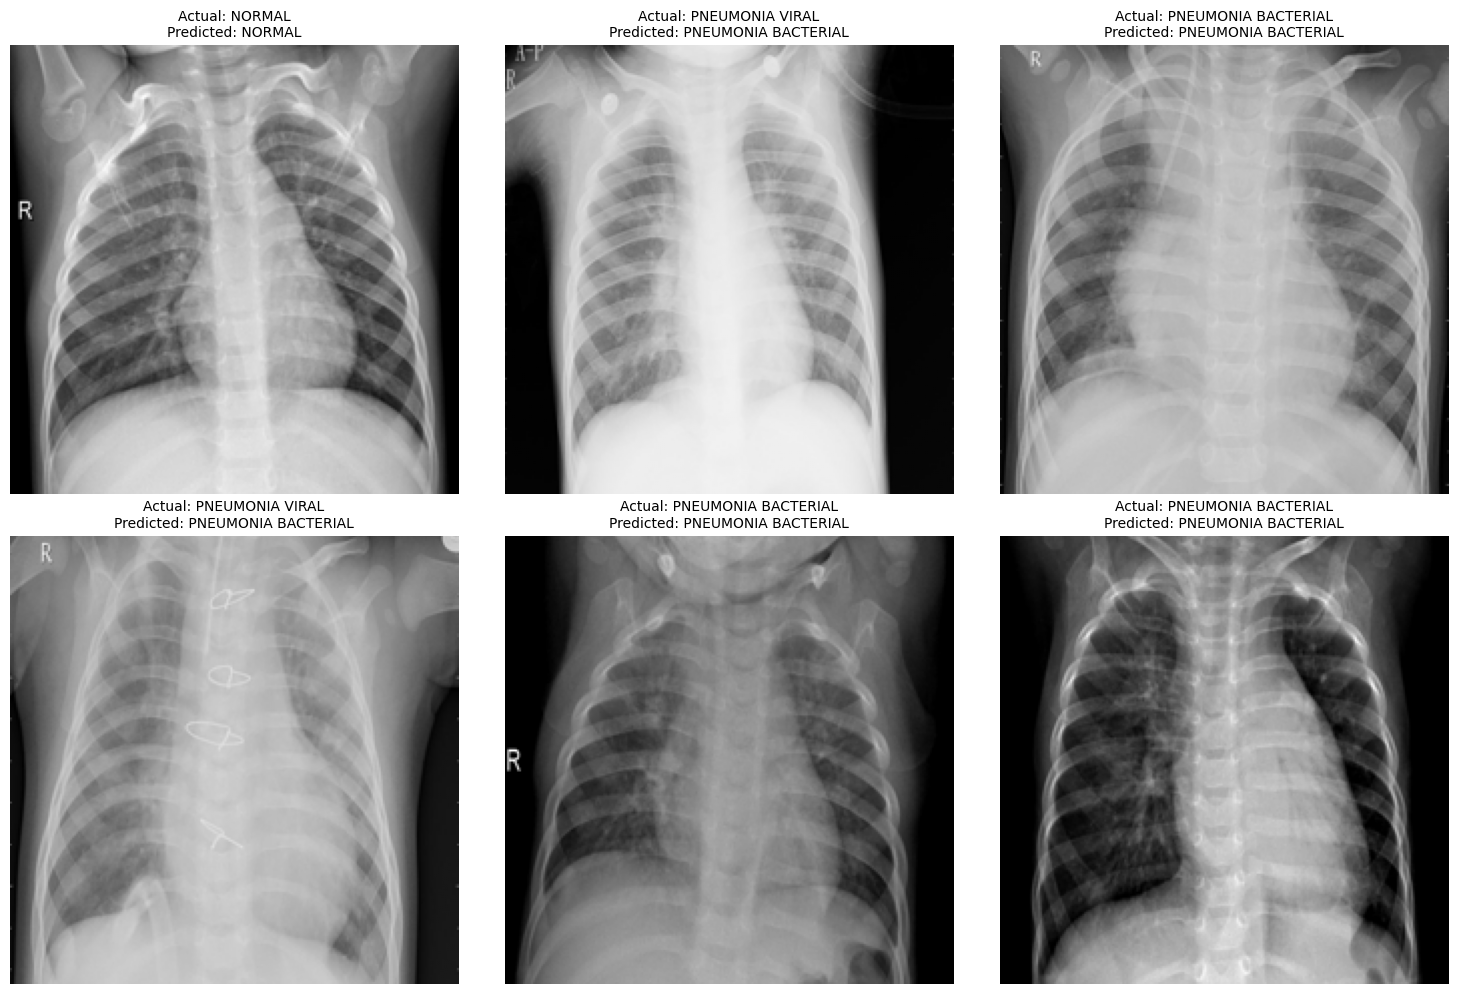

In [56]:

if best_model:
    # 2. Get all image paths from the test directory
    test_images_info = []
    for class_name in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_name)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    test_images_info.append({
                        'path': os.path.join(class_path, img_file),
                        'actual_class': class_name
                    })

    # Randomly select 6 images
    num_samples = 6
    random_samples = random.sample(test_images_info, min(num_samples, len(test_images_info)))

    # Reverse class_indices to map index to class name
    idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

    plt.figure(figsize=(15, 10))
    for i, sample in enumerate(random_samples):
        img_path = sample['path']
        actual_class = sample['actual_class']

        # Load and preprocess the image
        img = Image.open(img_path).convert('RGB') # Ensure 3 channels
        img = img.resize(img_size)
        img_array = np.array(img)
        img_array = img_array / 255.0  # Rescale
        img_input = np.expand_dims(img_array, axis=0) # Add batch dimension

        # Make prediction
        predictions = best_model.predict(img_input, verbose=0)
        predicted_class_idx = np.argmax(predictions, axis=1)[0]
        predicted_class = idx_to_class[predicted_class_idx]

        # Plot the image
        plt.subplot(2, 3, i + 1)
        plt.imshow(img_array)
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Could not proceed with predictions as the best model was not found.")

## **Grad-CAM**

In [60]:
def get_last_conv_layer_name(model, model_name):
    if "ResNet" in model_name:
        # Common last convolutional layer names for ResNet50
        for layer in reversed(model.layers):
            if 'conv5_block3' in layer.name and ('out' in layer.name or 'add' in layer.name or 'relu' in layer.name):
                return layer.name
        # Fallback to general search within the last block if specific name not found
        for layer in reversed(model.layers):
            if 'conv' in layer.name and 'block5' in layer.name:
                 return layer.name
        return 'conv5_block3_out' # Default if nothing else found
    elif "DenseNet" in model_name:
        # Common last convolutional layer names for DenseNet121
        for layer in reversed(model.layers):
            if 'conv5_block16' in layer.name and ('concat' in layer.name or 'relu' in layer.name):
                return layer.name
        return 'conv5_block16_concat' # Default
    elif "EfficientNet" in model_name:
        # Common last convolutional layer names for EfficientNetB0
        for layer in reversed(model.layers):
            if 'top_conv' in layer.name:
                return layer.name
            if 'block7a_project_bn' in layer.name:
                return layer.name
        return 'top_conv'
    return None

In [61]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [62]:
def display_gradcam(img_array_original, heatmap, alpha=0.4):

    heatmap_scaled = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_scaled]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img_array_original.shape[1], img_array_original.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap) # This will be 0-255

    superimposed_img = (jet_heatmap * alpha + img_array_original * (1 - alpha))
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    return superimposed_img

In [63]:
if 'best_model' not in locals() or best_model is None:
    best_model_row = metrics_df.loc[metrics_df['F1'].idxmax()]
    best_model_name = best_model_row['Model Name']
    if "ResNet" in best_model_name:
        best_model = resnet_model
    elif "DenseNet" in best_model_name:
        best_model = densenet_model
    elif "EfficientNet" in best_model_name:
        best_model = efficientnet_model
    else:
        print("Error: Best model not identified.")
        best_model = None


Using conv5_block3_out as the last convolutional layer for Grad-CAM for ResNet Model.


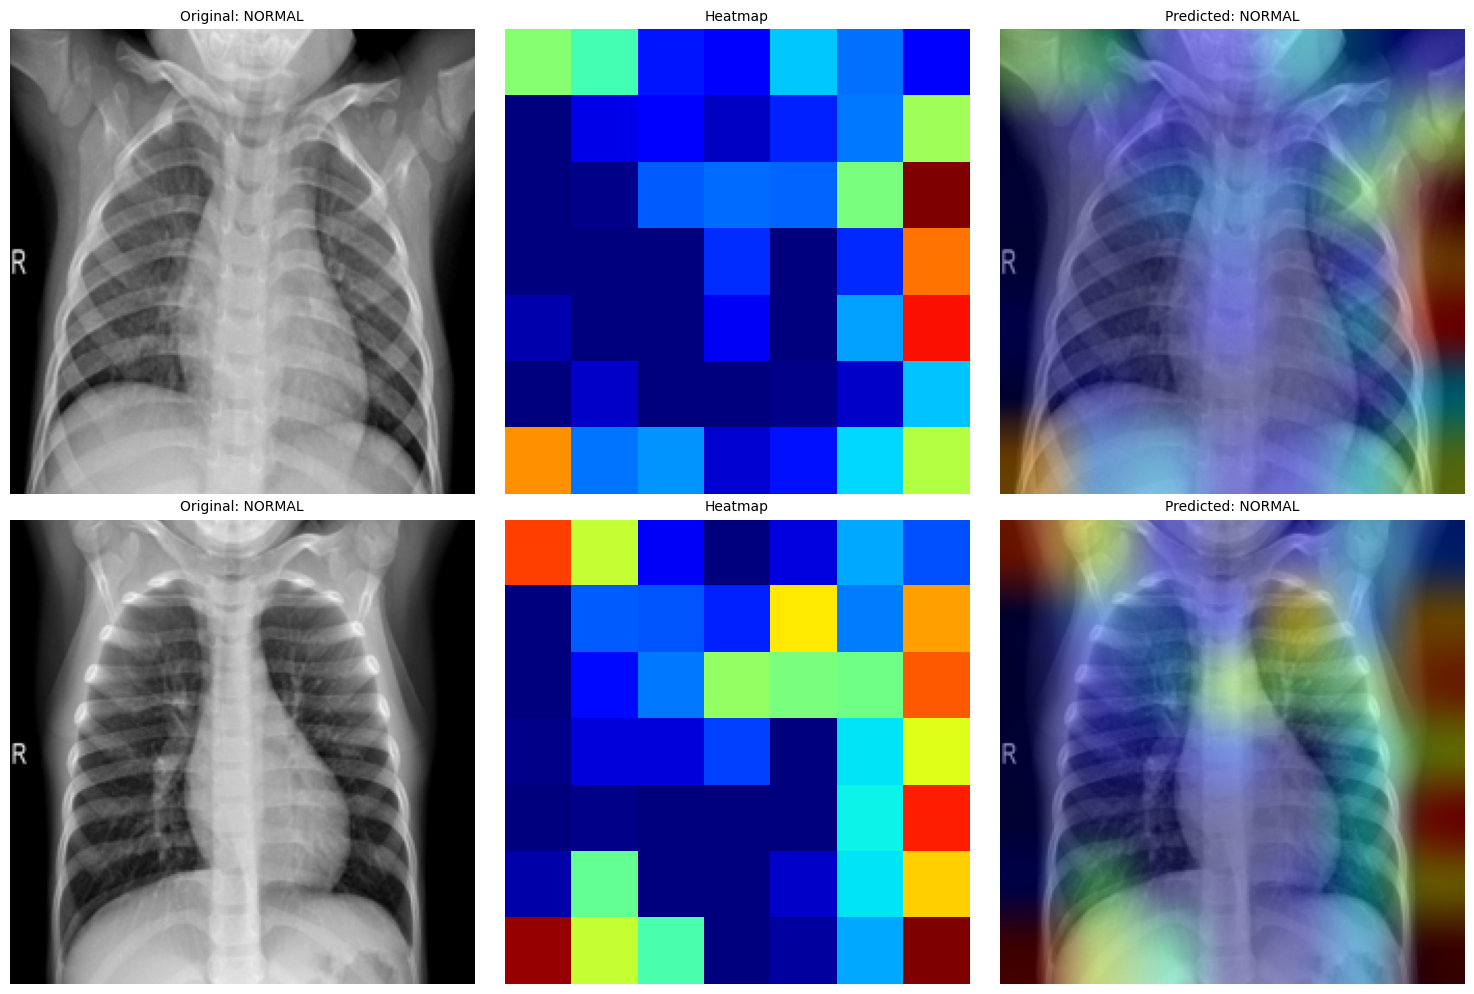

In [64]:
if best_model is None:
    print("Best model not found. Cannot proceed with Grad-CAM.")
else:
    # Identify the last convolutional layer dynamically or by known names
    last_conv_layer_name = get_last_conv_layer_name(best_model, best_model_name)

    if not last_conv_layer_name:
        print("Failed to identify a convolutional layer for Grad-CAM.")
    else:
        print(f"Using {last_conv_layer_name} as the last convolutional layer for Grad-CAM for {best_model_name}.")

        # 1. Get all image paths from the test directory
        test_images_info = []
        for class_name in os.listdir(test_dir):
            class_path = os.path.join(test_dir, class_name)
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        test_images_info.append({
                            'path': os.path.join(class_path, img_file),
                            'actual_class': class_name
                        })

        # Randomly select 2 images
        num_samples = 2
        random_samples = random.sample(test_images_info, min(num_samples, len(test_images_info)))

        # Reverse class_indices to map index to class name
        idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

        plt.figure(figsize=(15, 5 * num_samples)) # Adjust figure size dynamically
        for i, sample in enumerate(random_samples):
            img_path = sample['path']
            actual_class = sample['actual_class']

            # Load and preprocess the image
            img = Image.open(img_path).convert('RGB')
            img = img.resize(img_size) # Resize to model's expected input size
            img_array_original = np.array(img) # Keep original 0-255 for display and blending
            img_input_for_model = img_array_original / 255.0  # Normalize for model prediction
            img_input_for_model = np.expand_dims(img_input_for_model, axis=0) # Add batch dimension

            # Make prediction
            predictions = best_model.predict(img_input_for_model, verbose=0)
            predicted_class_idx = np.argmax(predictions, axis=1)[0]
            predicted_class = idx_to_class[predicted_class_idx]

            # Generate Grad-CAM heatmap
            heatmap = make_gradcam_heatmap(img_input_for_model, best_model, last_conv_layer_name, predicted_class_idx)

            # Display Grad-CAM superimposed image
            superimposed_img = display_gradcam(img_array_original, heatmap)

            # Plot original image
            plt.subplot(num_samples, 3, i * 3 + 1)
            plt.imshow(img_array_original)
            plt.title(f"Original: {actual_class}", fontsize=10)
            plt.axis("off")

            # Plot heatmap
            plt.subplot(num_samples, 3, i * 3 + 2)
            plt.imshow(heatmap, cmap="jet")
            plt.title("Heatmap", fontsize=10)
            plt.axis("off")

            # Plot superimposed image
            plt.subplot(num_samples, 3, i * 3 + 3)
            plt.imshow(superimposed_img)
            plt.title(f"Predicted: {predicted_class}", fontsize=10)
            plt.axis("off")

        plt.tight_layout()
        plt.show()